In [ ]:
!pip install wbgapi

In [ ]:
import wbgapi as wb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
indicators = {
    # === MEVCUT GÖSTERGELER ===
    'SP.DYN.LE00.IN': 'Yasam_Beklentisi',
    'SE.SEC.ENRR': 'Lise_Okullasma_Orani',
    'SH.XPD.CHEX.PC.CD': 'Kisi_Basi_Saglik_Harcamasi',
    'EN.ATM.PM25.MC.M3': 'Hava_Kirliligi_PM25',
    'EN.ATM.CO2E.KT': 'CO2_Emisyonu_KiloTon',
    'SP.POP.TOTL': 'Nufus',
    'SP.DYN.IMRT.IN': 'Bebek_Olum_Orani',
    'SH.DYN.MORT': 'Bes_Yas_Alti_Olum',
    'SH.IMM.HEPB': 'Asi_Hepatit_B',
    'SH.IMM.MEAS': 'Asi_Kizamik',
    'SH.IMM.POL3': 'Asi_Cocuk_Felci',
    'SH.IMM.IDPT': 'Asi_Difteri',
    'SH.DYN.AIDS.ZS': 'HIV_Prevalansi',
    'SH.ALC.PCAP.LI': 'Alkol_Tuketimi',

    # === YENİ: KARBON EMİSYONLARI ===
    'EN.ATM.CO2E.PC':   'CO2_Emisyonu_KisiBasI',      # ton/kişi
    'EN.ATM.METH.KT.CE':'Metan_Emisyonu_KT',           # CO2 eşdeğeri kt
    'EN.ATM.NOXE.KT.CE':'N2O_Emisyonu_KT',             # CO2 eşdeğeri kt
    'EN.ATM.GHGT.KT.CE':'Toplam_Sera_Gazi_KT',         # tüm GHG toplamı

    # === YENİ: ENERJİ & YAKIT ===
    'EG.FEC.RNEW.ZS':   'Yenilenebilir_Enerji_Payi',  # % toplam enerji
    'EG.USE.COMM.FO.ZS':'Fosil_Yakit_Tuketimi',        # % toplam enerji
    'EG.USE.PCAP.KG.OE':'Kisi_Basi_Enerji_Tuketimi',  # kg petrol eşdeğeri
    'EG.ELC.COAL.ZS':   'Komur_Elektrik_Payi',         # % elektrik üretimi
    'EG.ELC.RNWX.ZS':   'Yenilenebilir_Elektrik_Payi',# % elektrik üretimi

    # === YENİ: ORMAN KAYBI / ARAZİ KULLANIMI ===
    'AG.LND.FRST.ZS':   'Orman_Alani_Yuzdesi',         # % kara alanı
    'AG.LND.FRST.K2':   'Orman_Alani_KM2',             # km²
    'AG.LND.AGRI.ZS':   'Tarim_Arazisi_Yuzdesi',       # % kara alanı

    # === YENİ: SU KİRLİLİĞİ ===
    'EE.BOD.TOTL.KG':   'Su_BOD_Emisyonu_KG',          # kg/gün organik kirlilik
    'ER.H2O.FWTL.ZS':   'Tatli_Su_Cekim_Orani',        # % iç kaynaklar
    'SH.H2O.SMDW.ZS':   'Guvenli_Icme_Suyu_Erisimi',   # % nüfus
    'SH.STA.SMSS.ZS':   'Guvenli_Sanitasyon_Erisimi',  # % nüfus
}

print("Genişletilmiş veri seti Dünya Bankası'ndan çekiliyor, lütfen bekleyin...")

# 2. Adım: Veriyi Çekme (2000-2020)
raw_data = wb.data.DataFrame(indicators.keys(), time=range(2000, 2021), numericTimeKeys=True)

# 3. Adım: Veriyi Düzenleme (Geniş formattan Uzun formata)
df_reset = raw_data.reset_index()
df_melted = df_reset.melt(id_vars=['economy', 'series'], var_name='Yil', value_name='Deger')
df_final = df_melted.pivot_table(index=['economy', 'Yil'], columns='series', values='Deger').reset_index()

# Sütun isimlerini Türkçeleştirme
df_final.rename(columns=indicators, inplace=True)
df_final.rename(columns={'economy': 'Ulke_Kodu'}, inplace=True)

# 4. Adım: Ülke Meta Verilerini Çekme (Kıta ve Gelir Durumu)
countries = wb.economy.DataFrame()
meta_data = countries[['name', 'region', 'incomeLevel']].copy()
meta_data.rename(columns={
    'name': 'Ulke_Adi',
    'region': 'Bolge_Kodu',
    'incomeLevel': 'Gelismişlik_Durumu'
}, inplace=True)

# Verileri birleştirme
df_final = df_final.merge(meta_data, left_on='Ulke_Kodu', right_index=True, how='inner')

# 5. Adım: Sadece Avrupa ve Asya'yı Filtreleme
hedef_bolgeler = ['ECS', 'EAS', 'SAS']
df_filtered = df_final[df_final['Bolge_Kodu'].isin(hedef_bolgeler)].copy()

# İsimleri Türkçeleştirme
df_filtered['Kita'] = df_filtered['Bolge_Kodu'].map({
    'ECS': 'Avrupa ve Orta Asya', 'EAS': 'Doğu Asya ve Pasifik', 'SAS': 'Güney Asya'
})

df_filtered['Gelismişlik_Durumu'] = df_filtered['Gelismişlik_Durumu'].map({
    'HIC': 'Yüksek Gelirli (Gelişmiş)', 'UMC': 'Üst-Orta Gelirli',
    'LMC': 'Alt-Orta Gelirli', 'LIC': 'Düşük Gelirli (Gelişmemiş)', 'INX': 'Sınıflandırılmamış'
})

# 6. Adım: Dinamik Sütun Seçimi (Hata Önleyici Sistem)
temel_sutunlar = ['Ulke_Kodu', 'Ulke_Adi', 'Kita', 'Gelismişlik_Durumu', 'Yil']
veri_sutunlari = list(indicators.values())
istenen_sutunlar = temel_sutunlar + veri_sutunlari
mevcut_sutunlar = [col for col in istenen_sutunlar if col in df_filtered.columns]

# Nihai tabloyu oluştur ve sırala
df_analiz = df_filtered[mevcut_sutunlar].sort_values(by=['Ulke_Adi', 'Yil']).reset_index(drop=True)

print("\nVeri hazırlığı başarıyla tamamlandı!")
print(f"Toplam Satır Sayısı: {len(df_analiz)}")
print(f"Toplam Sütun (Değişken) Sayısı: {df_analiz.shape[1]}")
display(df_analiz.head())

Genişletilmiş veri seti Dünya Bankası'ndan çekiliyor, lütfen bekleyin...

Veri hazırlığı başarıyla tamamlandı!
Toplam Satır Sayısı: 2121
Toplam Sütun (Değişken) Sayısı: 28


,Ulke_Kodu,Ulke_Adi,Kita,Gelismişlik_Durumu,Yil,Yasam_Beklentisi,Lise_Okullasma_Orani,Kisi_Basi_Saglik_Harcamasi,Hava_Kirliligi_PM25,Nufus,...,Fosil_Yakit_Tuketimi,Kisi_Basi_Enerji_Tuketimi,Komur_Elektrik_Payi,Yenilenebilir_Elektrik_Payi,Orman_Alani_Yuzdesi,Orman_Alani_KM2,Tarim_Arazisi_Yuzdesi,Tatli_Su_Cekim_Orani,Guvenli_Icme_Suyu_Erisimi,Guvenli_Sanitasyon_Erisimi
0,ALB,Albania,Avrupa ve Orta Asya,Üst-Orta Gelirli,2000,74.826,70.318649,65.476746,22.265189,3089027.0,...,58.626225,581.374749,0.0,0.000000,28.076642,7693.00,41.751825,6.831970,49.138320,22.879987
1,ALB,Albania,Avrupa ve Orta Asya,Üst-Orta Gelirli,2001,75.083,72.484573,73.921715,22.366006,3060173.0,...,60.857697,598.228317,0.0,0.003753,28.123248,7705.77,41.569343,6.507286,49.081199,23.475974
2,ALB,Albania,Avrupa ve Orta Asya,Üst-Orta Gelirli,2002,75.299,74.538918,78.729095,22.482785,3051010.0,...,63.130793,661.117952,0.0,0.007223,28.169854,7718.54,41.605839,6.182602,48.984766,24.036737
3,ALB,Albania,Avrupa ve Orta Asya,Üst-Orta Gelirli,2003,75.557,77.751823,105.436676,22.593449,3039616.0,...,64.410168,649.357881,0.0,0.005409,28.216460,7731.31,40.912409,5.857918,48.885443,24.576771
4,ALB,Albania,Avrupa ve Orta Asya,Üst-Orta Gelirli,2004,75.951,78.980186,136.507248,22.675923,3026939.0,...,65.467668,716.623146,0.0,0.004816,28.263066,7744.08,40.948905,5.533234,50.717678,25.095910


In [ ]:
import wbgapi as wb
import pandas as pd

# Belirlediğimiz yeni göstergelerin kodları
new_indicators = {
    'IT.NET.USER.ZS': 'Internet_Usage',
    'SI.POV.GINI': 'Gini_Index',
    'IS.AIR.PSGR': 'Air_Passengers',
    'SH.STA.SUIC.P5': 'Suicide_Rate'
}

# Verileri çekme (Mevcut projenin tarih aralığına uygun: 2000-2020)
df_new = wb.data.DataFrame(new_indicators.keys(),
                           time=range(2000, 2021),
                           labels=True).rename(columns=new_indicators)

In [ ]:
import wbgapi as wb
import pandas as pd

# Mevcut ana veri setin: df_main
# Yeni çektiğin veri seti: df_new

# Belirlediğimiz yeni göstergelerin kodları (bu zaten yukarıda tanımlıydı, sadece referans için)
# new_indicators = {
#     'IT.NET.USER.ZS': 'Internet_Usage',
#     'SI.POV.GINI': 'Gini_Index',
#     'IS.AIR.PSGR': 'Air_Passengers'
# }

# Önemli: Yıl ve Ülke sütun isimlerinin aynı olduğundan emin olmalısın
# how='left' kullanarak ana veri setindeki satırları koruyoruz

# 1. Adım: Veriyi Çekme (2000-2020) - numericTimeKeys=True kullanılarak yıl sütunları oluşturulur
# df_new, cell jL8a_mhpBTIO'da zaten doğru şekilde çekiliyor ve indicator isimleri Türkçeleştiriliyor.
# Ancak yapısal olarak df_analiz ile aynı uzun formata getirilmesi gerekiyor.

# wb.data.DataFrame çıktısı, 'economy' ve 'series' MultiIndex'e ve yıl sütunlarına sahiptir.
# df_new'in ilk hali (rename sonrası): MultiIndex (economy, series), columns: 2000, ..., 2020 (indicator values)

# df_new (kernel state'e göre) MultiIndex (economy, series) ve kolonlar 'Ulke_Kodu', 'Internet_Usage', 'Gini_Index', 'Air_Passengers'
# ve yıl sütunları içeriyor gibi görünüyor, bu durum merge işlemini zorlaştırıyor.
# df_analiz'in oluşturulduğu yola benzer bir yol izleyelim:

# Yeni çekilen veriyi (df_new) düzgün birleştirilebilir hale getirelim
# df_new'in kolonlarını yeniden şekillendirmek için:

# df_new, jL8a_mhpBTIO hücresinde zaten indicators olarak isimlendirilmişti.
# Şimdi bu df_new'i df_analiz'in formatına benzetmeliyiz.
# Yani 'economy', 'Yil' (index olarak) ve indicator sütunları olan bir formata.

# Önceki hücredeki df_new yapısı:
# MultiIndex (economy, series)
# Columns: 'Internet_Usage', 'Gini_Index', 'Air_Passengers', ... (yıl bazında ayrı sütunlar)

# Yeni bir df_new_final oluşturmak için df_analiz'in oluşturulma mantığını takip edelim.
# jL8a_mhpBTIO hücresinde df_new zaten çekildi ve indicator'ler yeniden isimlendirildi.
# Ancak bu df_new'in formatı df_analiz ile direkt merge için uygun değil (col names for years, etc.).

# wb.data.DataFrame(new_indicators.keys(), time=range(2000, 2021), labels=True) çağrısı sonrası
# df_new'in yapısı: MultiIndex (economy, series), columns (yıllar 2000..2020)
# Sonra .rename(columns=new_indicators) ile indicator kodları isimlere dönüştürülüyor.
# Yani, df_new'in kolonları hala yıllar (2000, 2001, ..., 2020) ve index 'economy' ve 'series'.

# df_new_processed = df_new.reset_index()
# df_new_processed.rename(columns={'economy': 'Ulke_Kodu', 'Year': 'Yil'}, inplace=True)
# Bu kod 'Year' kolonu olmadığı için 'KeyError' vermişti.
# Ve df_new'de 'Ulke_Kodu' diye bir kolondan bahsediliyordu.

# Şimdi df_new'in yapısını df_analiz ile uyumlu hale getirelim:

# 1. df_new (jL8a_mhpBTIO'dan gelen) MultiIndex: (economy, series), Columns: (2000, 2001, ..., 2020)
#    Ancak 'labels=True' kullanıldığında indicator kolonlarının adları zaten new_indicators'tan geliyor.
#    Yani, df_new'in kolonları 'Internet_Usage', 'Gini_Index', 'Air_Passengers' ve satırları yıllara göre.
#    Kernel state'de df_new'in yapısı şu şekildeydi:
#    MultiIndex (economy, series), Kolon: Ulke_Kodu (country name), Internet_Usage, Gini_Index, Air_Passengers
#    Bu durum, wbgapi'nin labels=True ile hem indicator adlarını kolon yapıp, hem de country adını 'Ulke_Kodu' kolonu olarak getirmesinden kaynaklanıyor olabilir.

# En doğru yaklaşım, df_analiz'in oluşturulma mantığını takip etmektir:
# df_new'in orijinal halini (jL8a_mhpBTIO hücresindeki gibi) alıp, onu melt ve pivot etmektir.

# Tekrar çekerek standart wbgapi çıktısını alıp işlemek en güvenlisi:
# Raw data'yı çekelim (numericTimeKeys=True ile yıl sütunları olsun)
raw_new_data_for_merge = wb.data.DataFrame(new_indicators.keys(), time=range(2000, 2021), numericTimeKeys=True)

# Reset index (economy ve series kolon olur, yıl kolonları kalır)
df_new_reset = raw_new_data_for_merge.reset_index()

# Melt işlemi (yılları 'Yil' kolonu, değerleri 'Deger' kolonu yapar)
df_new_melted = df_new_reset.melt(id_vars=['economy', 'series'], var_name='Yil', value_name='Deger')

# Pivot işlemi (indicator'ları ayrı kolon yapar)
df_new_final = df_new_melted.pivot_table(index=['economy', 'Yil'], columns='series', values='Deger').reset_index()

# Kolon isimlerini df_analiz ile uyumlu hale getir
df_new_final.rename(columns={'economy': 'Ulke_Kodu'}, inplace=True)
df_new_final.rename(columns=new_indicators, inplace=True)

# df_analiz ile birleştir
df_combined = pd.merge(df_analiz, df_new_final, on=['Ulke_Kodu', 'Yil'], how='left')

# df_combined'ın ilk birkaç satırını göster
# display(df_combined.head())

In [ ]:
df_combined['Air_Passengers_Per_Capita'] = df_combined['Air_Passengers'] / df_combined['Nufus']

df_combined['Forest_Area_Per_Capita'] = df_combined['Orman_Alani_KM2'] / df_combined['Nufus']

In [ ]:
df_combined['Is_Pandemic'] = (df_combined['Yil'] == 2020).astype(int)

In [ ]:
display(df_combined.head())

,Ulke_Kodu,Ulke_Adi,Kita,Gelismişlik_Durumu,Yil,Yasam_Beklentisi,Lise_Okullasma_Orani,Kisi_Basi_Saglik_Harcamasi,Hava_Kirliligi_PM25,Nufus,...,Tatli_Su_Cekim_Orani,Guvenli_Icme_Suyu_Erisimi,Guvenli_Sanitasyon_Erisimi,Air_Passengers,Internet_Usage,Suicide_Rate,Gini_Index,Air_Passengers_Per_Capita,Forest_Area_Per_Capita,Is_Pandemic
0,ALB,Albania,Avrupa ve Orta Asya,Üst-Orta Gelirli,2000,74.826,70.318649,65.476746,22.265189,3089027.0,...,6.831970,49.138320,22.879987,136622.0,0.114097,4.78,NaN,0.044228,0.002490,0
1,ALB,Albania,Avrupa ve Orta Asya,Üst-Orta Gelirli,2001,75.083,72.484573,73.921715,22.366006,3060173.0,...,6.507286,49.081199,23.475974,146273.0,0.325798,4.19,NaN,0.047799,0.002518,0
2,ALB,Albania,Avrupa ve Orta Asya,Üst-Orta Gelirli,2002,75.299,74.538918,78.729095,22.482785,3051010.0,...,6.182602,48.984766,24.036737,137569.0,0.390081,4.28,31.7,0.045090,0.002530,0
3,ALB,Albania,Avrupa ve Orta Asya,Üst-Orta Gelirli,2003,75.557,77.751823,105.436676,22.593449,3039616.0,...,5.857918,48.885443,24.576771,158888.0,0.971900,4.47,NaN,0.052272,0.002544,0
4,ALB,Albania,Avrupa ve Orta Asya,Üst-Orta Gelirli,2004,75.951,78.980186,136.507248,22.675923,3026939.0,...,5.533234,50.717678,25.095910,179543.0,2.420388,4.44,NaN,0.059315,0.002558,0


In [ ]:
# Colab'den dosya indirmek için gerekli kütüphane
from google.colab import files

# Veri setini Excel dosyası olarak kaydetme
# index=False komutu, satır numaralarının Excel'e gereksiz bir sütun olarak eklenmesini önler
dosya_adi = 'Life_Expectancy.xlsx'
df_combined.to_excel(dosya_adi, index=False)

print(f"{dosya_adi} oluşturuldu. Bilgisayarınıza indiriliyor...")

# Dosyayı otomatik olarak bilgisayarınıza indirme komutu
files.download(dosya_adi)

Life_Expectancy.xlsx oluşturuldu. Bilgisayarınıza indiriliyor...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df_combined.shape

(2121, 35)

In [ ]:
print(df_combined.columns.tolist())

['Ulke_Kodu', 'Ulke_Adi', 'Kita', 'Gelismişlik_Durumu', 'Yil', 'Yasam_Beklentisi', 'Lise_Okullasma_Orani', 'Kisi_Basi_Saglik_Harcamasi', 'Hava_Kirliligi_PM25', 'Nufus', 'Bebek_Olum_Orani', 'Bes_Yas_Alti_Olum', 'Asi_Hepatit_B', 'Asi_Kizamik', 'Asi_Difteri', 'HIV_Prevalansi', 'Alkol_Tuketimi', 'Yenilenebilir_Enerji_Payi', 'Fosil_Yakit_Tuketimi', 'Kisi_Basi_Enerji_Tuketimi', 'Komur_Elektrik_Payi', 'Yenilenebilir_Elektrik_Payi', 'Orman_Alani_Yuzdesi', 'Orman_Alani_KM2', 'Tarim_Arazisi_Yuzdesi', 'Tatli_Su_Cekim_Orani', 'Guvenli_Icme_Suyu_Erisimi', 'Guvenli_Sanitasyon_Erisimi', 'Air_Passengers', 'Internet_Usage', 'Suicide_Rate', 'Gini_Index', 'Air_Passengers_Per_Capita', 'Forest_Area_Per_Capita', 'Is_Pandemic']


In [ ]:
df_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2121 entries, 0 to 2120
Data columns (total 35 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Ulke_Kodu                    2121 non-null   object 
 1   Ulke_Adi                     2121 non-null   object 
 2   Kita                         2121 non-null   object 
 3   Gelismişlik_Durumu           2121 non-null   object 
 4   Yil                          2121 non-null   int64  
 5   Yasam_Beklentisi             2121 non-null   float64
 6   Lise_Okullasma_Orani         1459 non-null   float64
 7   Kisi_Basi_Saglik_Harcamasi   1800 non-null   float64
 8   Hava_Kirliligi_PM25          1911 non-null   float64
 9   Nufus                        2121 non-null   float64
 10  Bebek_Olum_Orani             1848 non-null   float64
 11  Bes_Yas_Alti_Olum            1848 non-null   float64
 12  Asi_Hepatit_B                1535 non-null   float64
 13  Asi_Kizamik       

In [ ]:
eksik_veriler = df_combined.isnull().sum()
print("Eksik Veri Sayıları:")
print(eksik_veriler[eksik_veriler > 0])

eksik_yuzde = (df_combined.isnull().sum() / len(df_combined)) * 100
print("\nEksik Veri Yüzdesi (%):")
print(eksik_yuzde[eksik_yuzde > 0])

Eksik Veri Sayıları:
Lise_Okullasma_Orani            662
Kisi_Basi_Saglik_Harcamasi      321
Hava_Kirliligi_PM25             210
Bebek_Olum_Orani                273
Bes_Yas_Alti_Olum               273
Asi_Hepatit_B                   586
Asi_Kizamik                     302
Asi_Difteri                     302
HIV_Prevalansi                  929
Alkol_Tuketimi                  414
Yenilenebilir_Enerji_Payi        93
Fosil_Yakit_Tuketimi            636
Kisi_Basi_Enerji_Tuketimi       580
Komur_Elektrik_Payi             159
Yenilenebilir_Elektrik_Payi     159
Orman_Alani_Yuzdesi              75
Orman_Alani_KM2                  75
Tarim_Arazisi_Yuzdesi            96
Tatli_Su_Cekim_Orani            642
Guvenli_Icme_Suyu_Erisimi       337
Guvenli_Sanitasyon_Erisimi      531
Air_Passengers                  502
Internet_Usage                  227
Suicide_Rate                    441
Gini_Index                     1097
Air_Passengers_Per_Capita       502
Forest_Area_Per_Capita           75
dtype: 

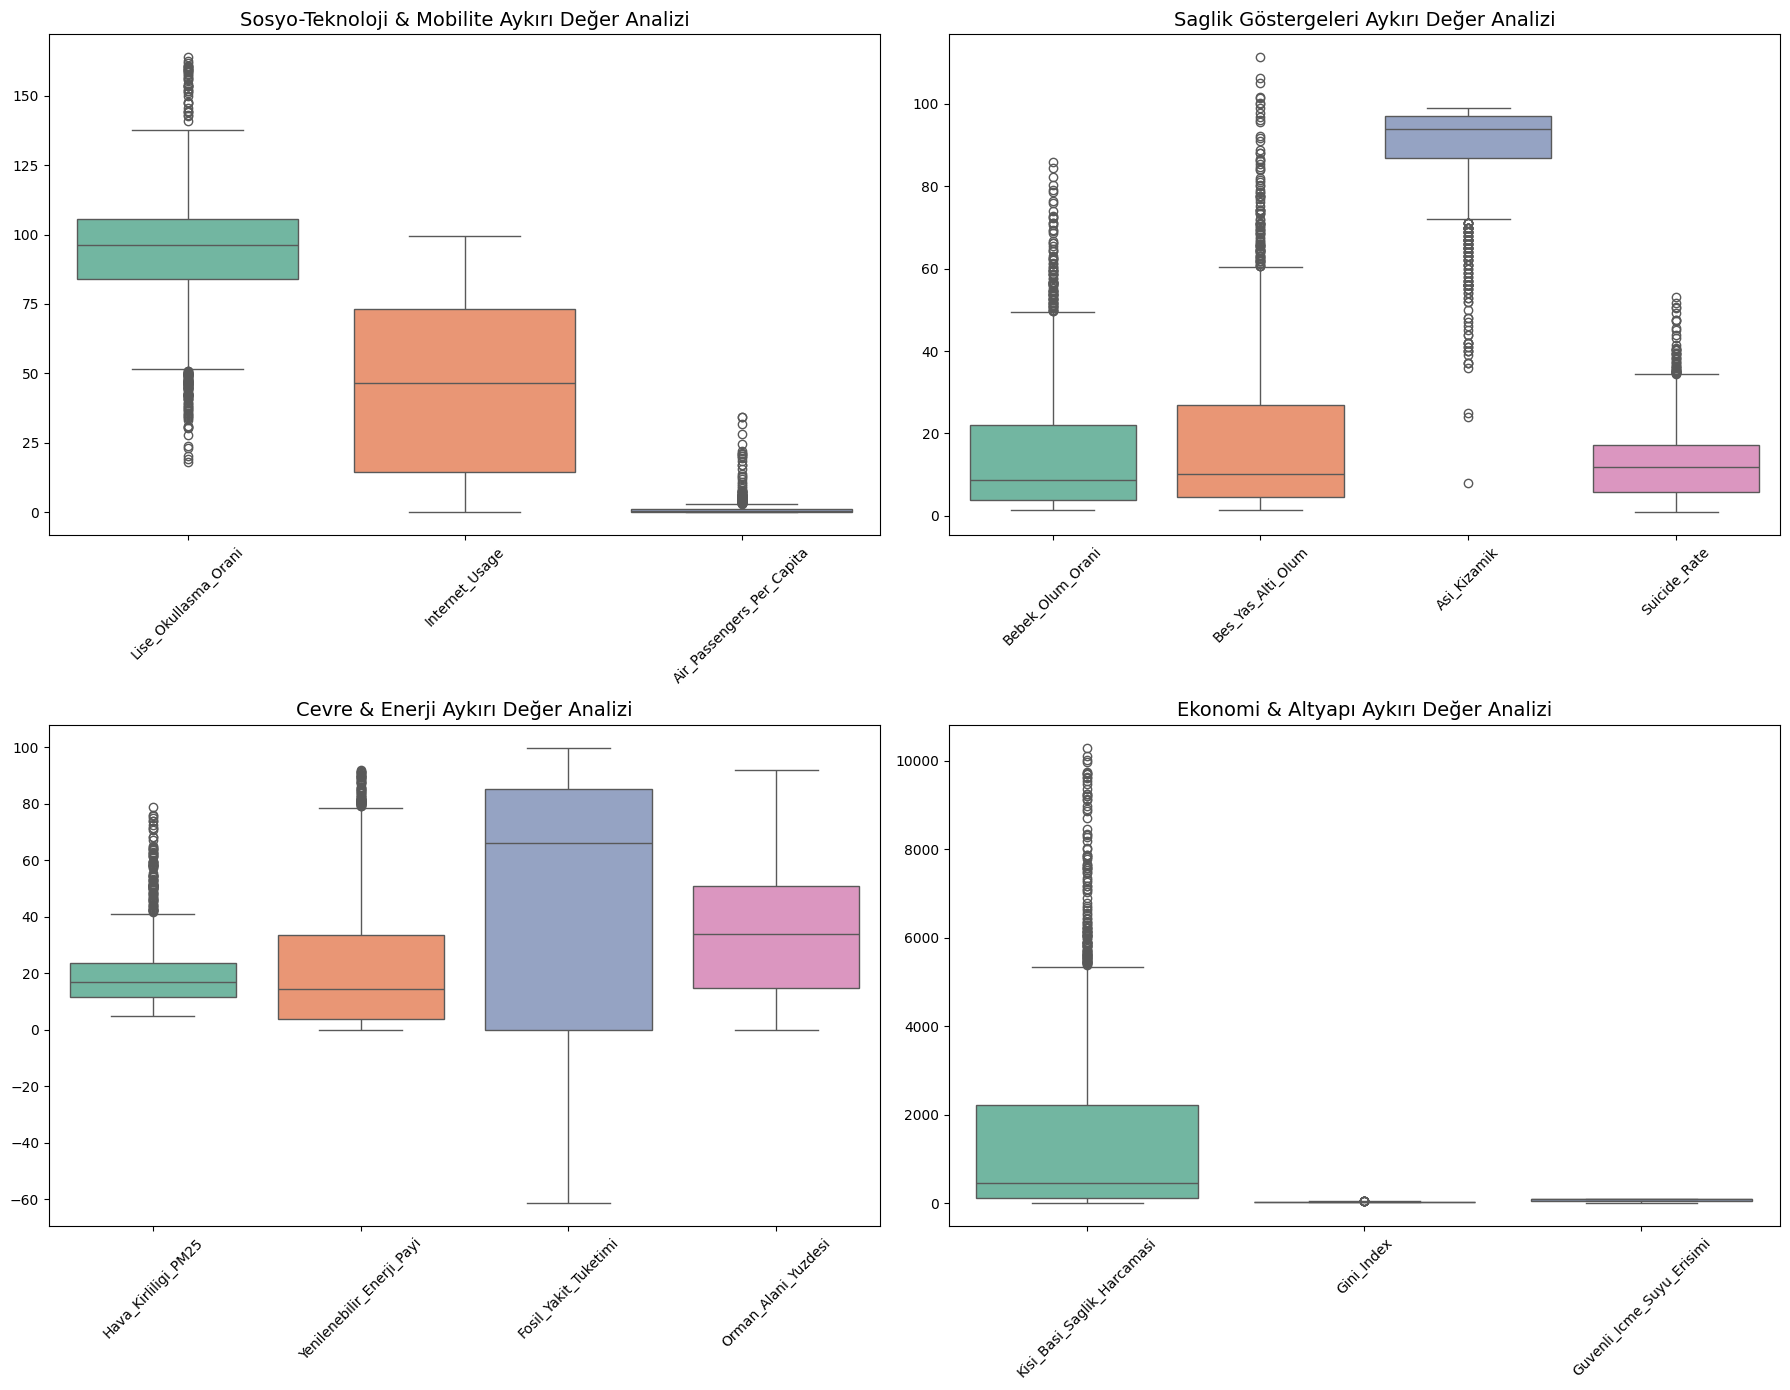

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Grupları tanımlayalım (Analiz kolaylığı için)
gruplar = {
    "Sosyo-Teknoloji & Mobilite": ['Lise_Okullasma_Orani', 'Internet_Usage', 'Air_Passengers_Per_Capita'],
    "Saglik Göstergeleri": ['Bebek_Olum_Orani', 'Bes_Yas_Alti_Olum', 'Asi_Kizamik', 'Suicide_Rate'],
    "Cevre & Enerji": ['Hava_Kirliligi_PM25', 'Yenilenebilir_Enerji_Payi', 'Fosil_Yakit_Tuketimi', 'Orman_Alani_Yuzdesi'],
    "Ekonomi & Altyapı": ['Kisi_Basi_Saglik_Harcamasi', 'Gini_Index', 'Guvenli_Icme_Suyu_Erisimi']
}

# 4 farklı subplot oluşturuyoruz
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

for i, (grup_adi, sutunlar) in enumerate(gruplar.items()):
    sns.boxplot(data=df_combined[sutunlar], ax=axes[i], palette="Set2")
    axes[i].set_title(f'{grup_adi} Aykırı Değer Analizi', fontsize=14)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# 1. Önce veriyi ülke ve yıl bazında sıralayalım (Zaman serisi mantığı için kritik)
df_combined = df_combined.sort_values(['Ulke_Adi', 'Yil'])

# 2. Ülke Bazlı İnterpolasyon (Interpolate)
# Bir ülkenin verisi yıllar arasında eksikse (örn: 2010 var, 2011 yok, 2012 var),
# aradaki boşluğu lineer bir trendle doldurur.
df_combined = df_combined.groupby('Ulke_Adi').apply(
    lambda x: x.interpolate(method='linear', limit_direction='both')
).reset_index(drop=True)

# 3. Kıta/Bölge Bazlı Ortalama (Fillna)
# Eğer bir ülkenin o değişkene dair hiçbir verisi yoksa, bulunduğu kıtanın
# o değişken için genel ortalamasını kullanır.
df_combined = df_combined.groupby('Kita').apply(
    lambda x: x.fillna(x.mean(numeric_only=True))
).reset_index(drop=True)

# 4. Genel Ortalama (Son Çare)
# Nadiren de olsa kıtada da veri yoksa, tüm veri setinin ortalamasını basar.
df_combined = df_combined.fillna(df_combined.mean(numeric_only=True))

print("df_combined için eksik veri tamamlama tamamlandı!")
print("Kalan boş değer sayısı:", df_combined.isnull().sum().sum())

/tmp/ipykernel_3927/1678698940.py:8: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  lambda x: x.interpolate(method='linear', limit_direction='both')
/tmp/ipykernel_3927/1678698940.py:8: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  lambda x: x.interpolate(method='linear', limit_direction='both')
/tmp/ipykernel_3927/1678698940.py:8: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  lambda x: x.interpolate(method='linear', limit_direction='both')
/tmp/ipykernel_3927/1678698940.py:8: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) b

df_combined için eksik veri tamamlama tamamlandı!
Kalan boş değer sayısı: 0


/tmp/ipykernel_3927/1678698940.py:8: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  lambda x: x.interpolate(method='linear', limit_direction='both')
/tmp/ipykernel_3927/1678698940.py:8: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  lambda x: x.interpolate(method='linear', limit_direction='both')
/tmp/ipykernel_3927/1678698940.py:8: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  lambda x: x.interpolate(method='linear', limit_direction='both')
/tmp/ipykernel_3927/1678698940.py:8: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) b

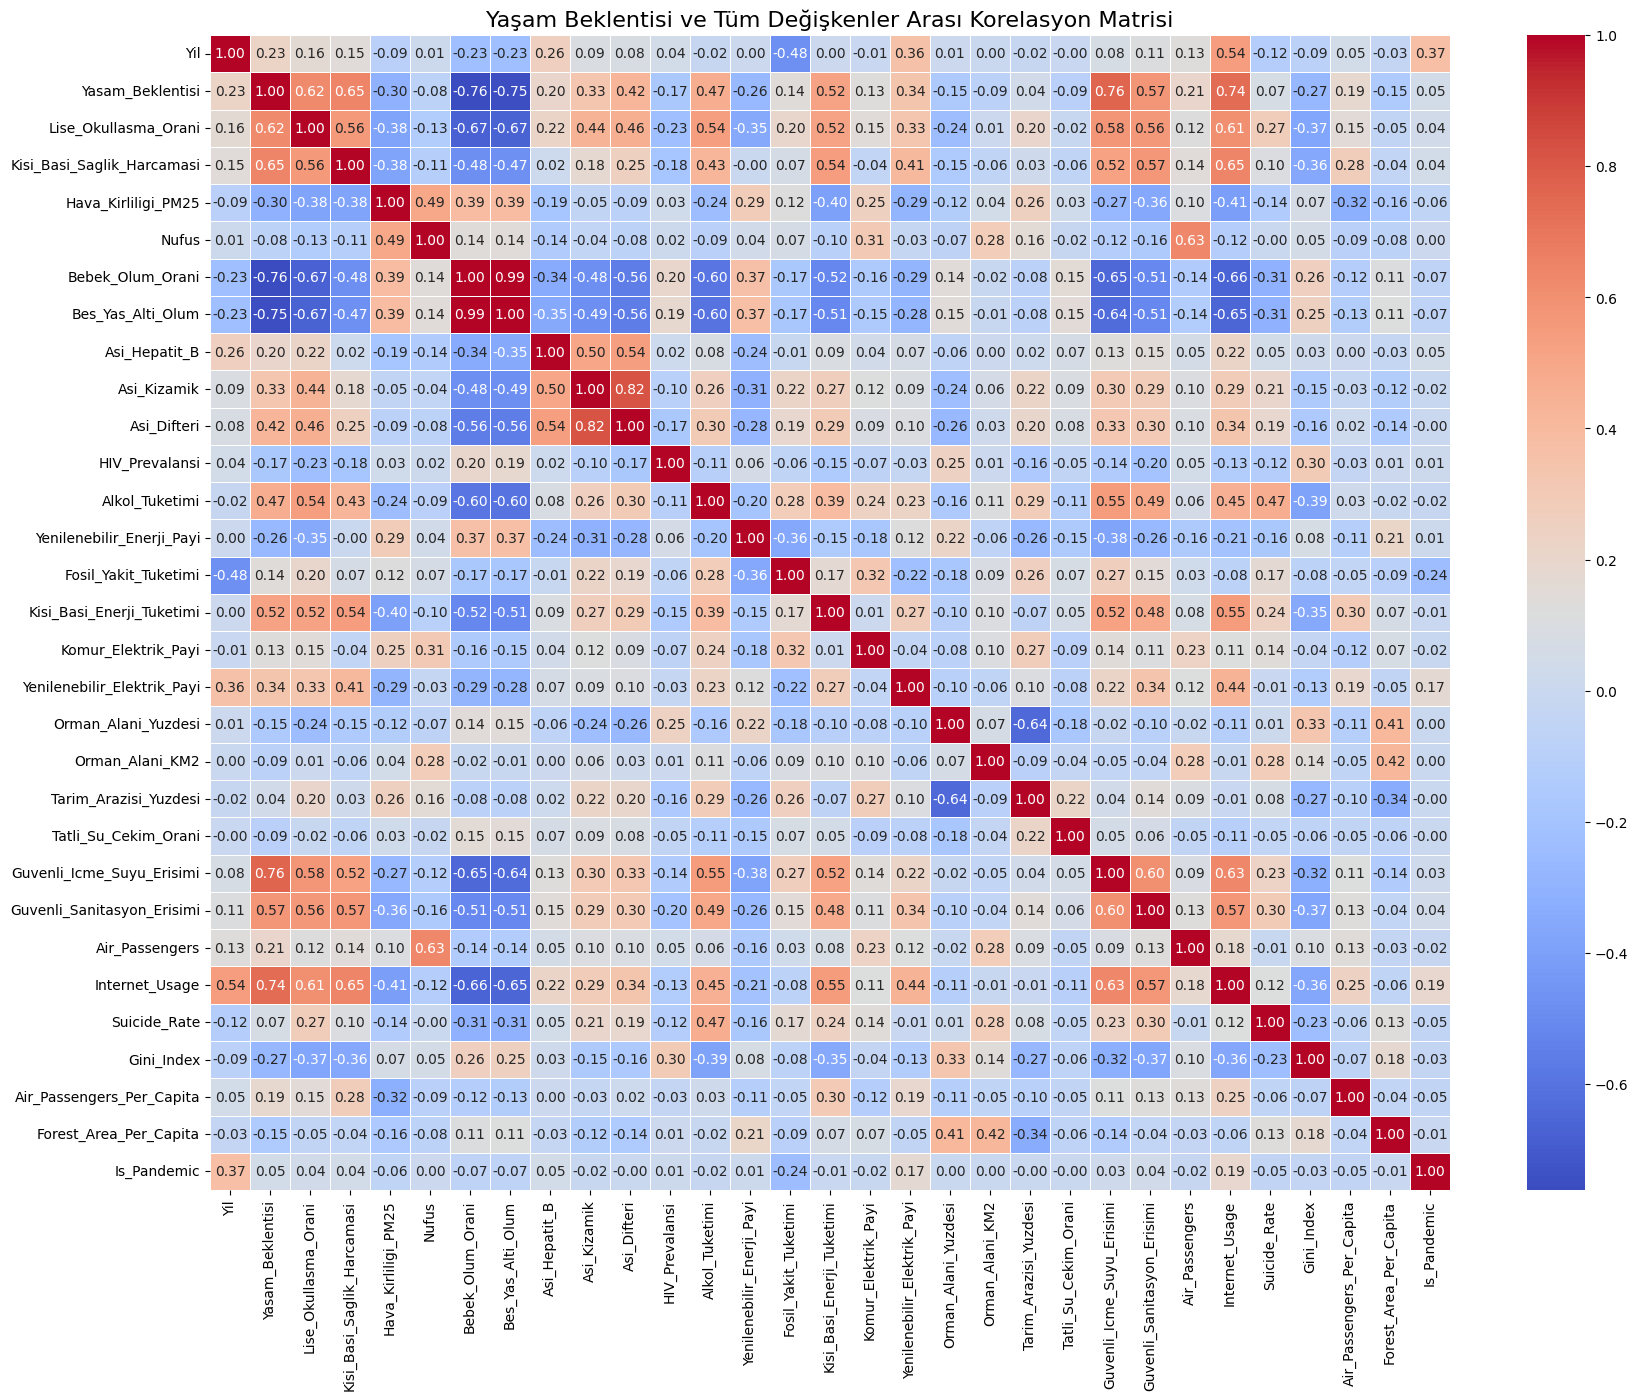

In [ ]:
import numpy as np

# Sadece sayısal sütunları seçelim
numeric_cols = df_combined.select_dtypes(include=[np.number]).columns

# Korelasyon matrisini hesapla
corr_matrix = df_combined[numeric_cols].corr()

# Isı haritasını çizdir
plt.figure(figsize=(20, 15))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Yaşam Beklentisi ve Tüm Değişkenler Arası Korelasyon Matrisi', fontsize=16)
plt.show()

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# 1. Normalizasyon için kullanılacak sütunları seçiyoruz
# Not: Air_Passengers yerine yeni oluşturduğum kişi başı veriyi kullanıyoruz
stme_cols = ['Lise_Okullasma_Orani', 'Internet_Usage', 'Air_Passengers_Per_Capita']

# 2. MinMaxScaler tanımlama ve uygulama
scaler = MinMaxScaler()
df_combined_norm = pd.DataFrame(scaler.fit_transform(df_combined[stme_cols]),
                       columns=[c + '_Norm' for c in stme_cols],
                       index=df_combined.index)

agirliklar_STME = {
    'Lise_Norm': 0.45,
    'Internet_Norm': 0.30,
    'Havacilik_Norm': 0.25
}

# 3. Endeksi Hesaplama
df_combined['Sosyo_Teknolojik_Mobilite_Endeksi'] = (
    df_combined_norm['Lise_Okullasma_Orani_Norm'] * agirliklar_STME['Lise_Norm'] +
    df_combined_norm['Internet_Usage_Norm'] * agirliklar_STME['Internet_Norm'] +
    df_combined_norm['Air_Passengers_Per_Capita_Norm'] * agirliklar_STME['Havacilik_Norm']
)

print("STME Endeksi Başarıyla Oluşturuldu!")

STME Endeksi Başarıyla Oluşturuldu!


In [ ]:
# 1. Değişkenleri seç ve normalizasyon yap
sbe_cols = ['Kisi_Basi_Saglik_Harcamasi', 'Bebek_Olum_Orani', 'Bes_Yas_Alti_Olum',
            'Asi_Kizamik', 'Asi_Difteri', 'Asi_Hepatit_B', 'HIV_Prevalansi']

scaler_sbe = MinMaxScaler()
df_sbe_norm = pd.DataFrame(scaler_sbe.fit_transform(df_combined[sbe_cols]),
                           columns=[c + '_Norm' for c in sbe_cols], index=df_combined.index)

# 2. Ters Çevirme (Düşük olması iyi olanlar: Ölüm oranları ve HIV)
df_sbe_norm['Bebek_Olum_Inverted'] = 1 - df_sbe_norm['Bebek_Olum_Orani_Norm']
df_sbe_norm['Bes_Yas_Alti_Inverted'] = 1 - df_sbe_norm['Bes_Yas_Alti_Olum_Norm']
df_sbe_norm['HIV_Inverted'] = 1 - df_sbe_norm['HIV_Prevalansi_Norm']

# 3. Ağırlıklı Hesaplama
df_combined['Saglik_Bagisiklik_Endeksi'] = (
    df_sbe_norm['Bebek_Olum_Inverted'] * 0.25 +
    df_sbe_norm['Bes_Yas_Alti_Inverted'] * 0.25 +
    df_sbe_norm['Kisi_Basi_Saglik_Harcamasi_Norm'] * 0.20 +
    df_sbe_norm['Asi_Kizamik_Norm'] * 0.10 +
    df_sbe_norm['Asi_Difteri_Norm'] * 0.10 +
    df_sbe_norm['Asi_Hepatit_B_Norm'] * 0.05 +
    df_sbe_norm['HIV_Inverted'] * 0.05
)

In [ ]:
cke_cols = ['Hava_Kirliligi_PM25', 'Yenilenebilir_Enerji_Payi', 'Fosil_Yakit_Tuketimi',
            'Orman_Alani_Yuzdesi', 'Forest_Area_Per_Capita']

scaler_cke = MinMaxScaler()
df_cke_norm = pd.DataFrame(scaler_cke.fit_transform(df_combined[cke_cols]),
                           columns=[c + '_Norm' for c in cke_cols], index=df_combined.index)

# Ters Çevirme (Kirlilik ve Fosil Yakıt)
df_cke_norm['Hava_Kirliligi_Inverted'] = 1 - df_cke_norm['Hava_Kirliligi_PM25_Norm']
df_cke_norm['Fosil_Yakit_Inverted'] = 1 - df_cke_norm['Fosil_Yakit_Tuketimi_Norm']

# Ağırlıklı Hesaplama
df_combined['Cevresel_Kalite_Endeksi'] = (
    df_cke_norm['Hava_Kirliligi_Inverted'] * 0.35 +
    df_cke_norm['Yenilenebilir_Enerji_Payi_Norm'] * 0.25 +
    df_cke_norm['Fosil_Yakit_Inverted'] * 0.20 +
    df_cke_norm['Orman_Alani_Yuzdesi_Norm'] * 0.10 +
    df_cke_norm['Forest_Area_Per_Capita_Norm'] * 0.10
)

In [ ]:
take_cols = ['Guvenli_Icme_Suyu_Erisimi', 'Guvenli_Sanitasyon_Erisimi', 'Tarim_Arazisi_Yuzdesi', 'Tatli_Su_Cekim_Orani']

scaler_take = MinMaxScaler()
df_take_norm = pd.DataFrame(scaler_take.fit_transform(df_combined[take_cols]),
                            columns=[c + '_Norm' for c in take_cols], index=df_combined.index)

# Ağırlıklı Hesaplama
df_combined['Temel_Altyapi_Kaynak_Endeksi'] = (
    df_take_norm['Guvenli_Icme_Suyu_Erisimi_Norm'] * 0.40 +
    df_take_norm['Guvenli_Sanitasyon_Erisimi_Norm'] * 0.30 +
    df_take_norm['Tarim_Arazisi_Yuzdesi_Norm'] * 0.15 +
    df_take_norm['Tatli_Su_Cekim_Orani_Norm'] * 0.15
)

In [ ]:
srae_cols = ['Gini_Index', 'Suicide_Rate', 'Alkol_Tuketimi']

scaler_srae = MinMaxScaler()
df_srae_norm = pd.DataFrame(scaler_srae.fit_transform(df_combined[srae_cols]),
                            columns=[c + '_Norm' for c in srae_cols], index=df_combined.index)

# Tüm değişkenler ters çevrilmeli (Düşük olması daha iyidir)
df_srae_norm['Gini_Inverted'] = 1 - df_srae_norm['Gini_Index_Norm']
df_srae_norm['Suicide_Inverted'] = 1 - df_srae_norm['Suicide_Rate_Norm']
df_srae_norm['Alkol_Inverted'] = 1 - df_srae_norm['Alkol_Tuketimi_Norm']

# Ağırlıklı Hesaplama
df_combined['Sosyal_Risk_Adalet_Endeksi'] = (
    df_srae_norm['Gini_Inverted'] * 0.50 +
    df_srae_norm['Suicide_Inverted'] * 0.30 +
    df_srae_norm['Alkol_Inverted'] * 0.20
)

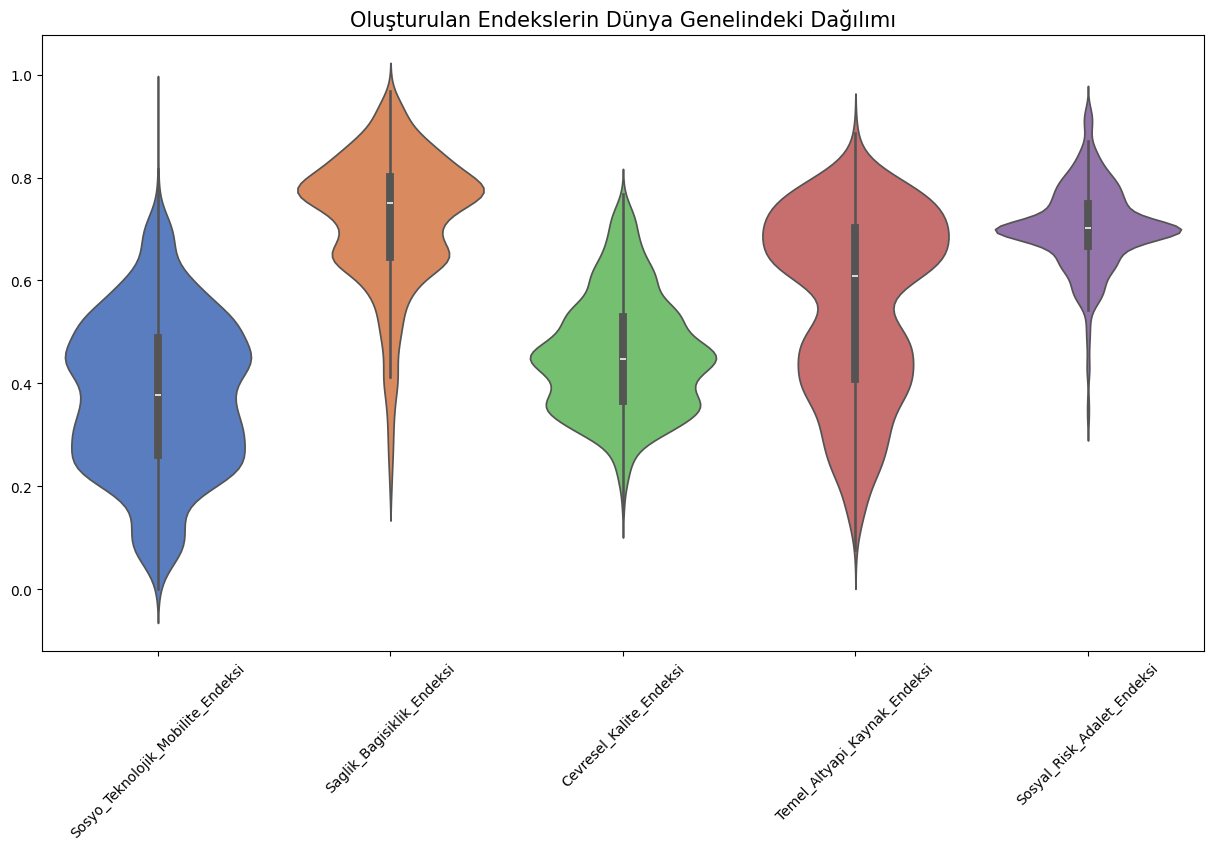

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Endeks listesi
endeksler = ['Sosyo_Teknolojik_Mobilite_Endeksi', 'Saglik_Bagisiklik_Endeksi',
             'Cevresel_Kalite_Endeksi', 'Temel_Altyapi_Kaynak_Endeksi', 'Sosyal_Risk_Adalet_Endeksi']

plt.figure(figsize=(15, 8))
sns.violinplot(data=df_combined[endeksler], palette="muted")
plt.xticks(rotation=45)
plt.title('Oluşturulan Endekslerin Dünya Genelindeki Dağılımı', fontsize=15)
plt.show()

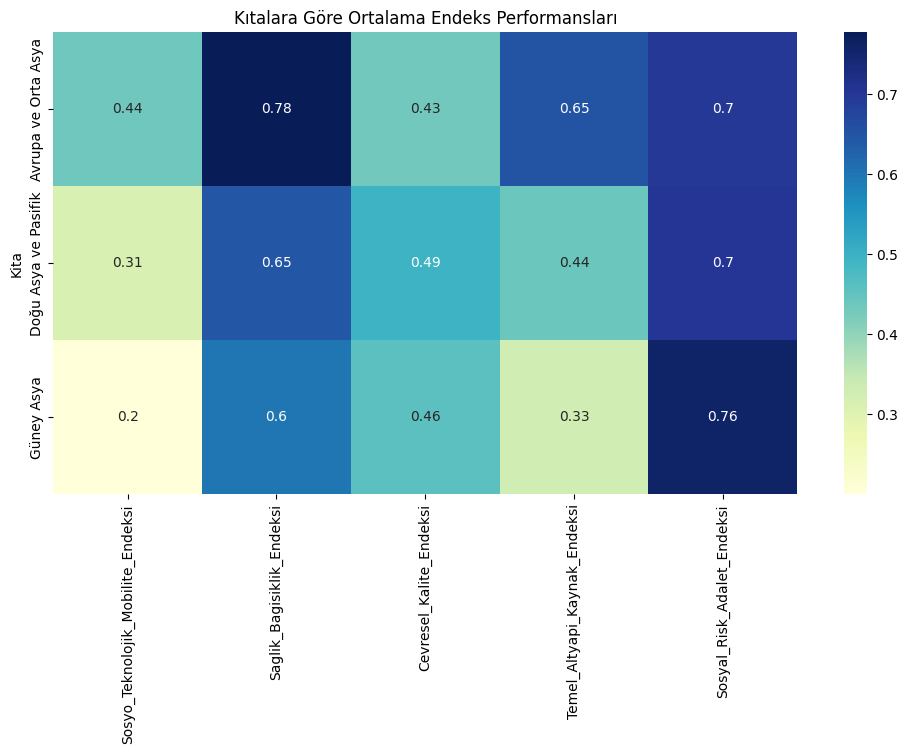

In [ ]:
# Kıta bazında endeks ortalamaları
kita_analizi = df_combined.groupby('Kita')[endeksler].mean()

# Isı haritası ile görselleştirme
plt.figure(figsize=(12, 6))
sns.heatmap(kita_analizi, annot=True, cmap="YlGnBu")
plt.title('Kıtalara Göre Ortalama Endeks Performansları')
plt.show()

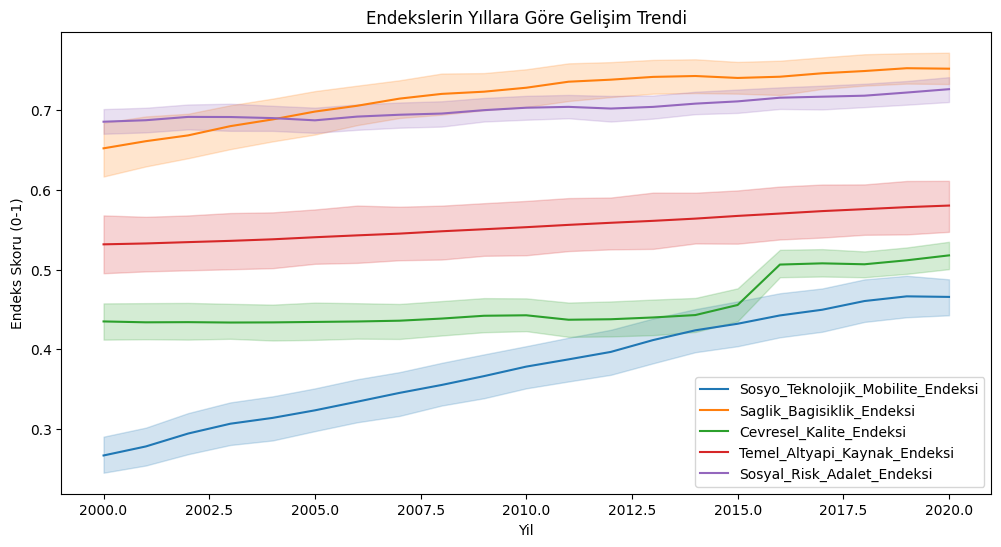

In [ ]:
plt.figure(figsize=(12, 6))
for endeks in endeksler:
    sns.lineplot(data=df_combined, x='Yil', y=endeks, label=endeks)

plt.title('Endekslerin Yıllara Göre Gelişim Trendi')
plt.ylabel('Endeks Skoru (0-1)')
plt.legend()
plt.show()

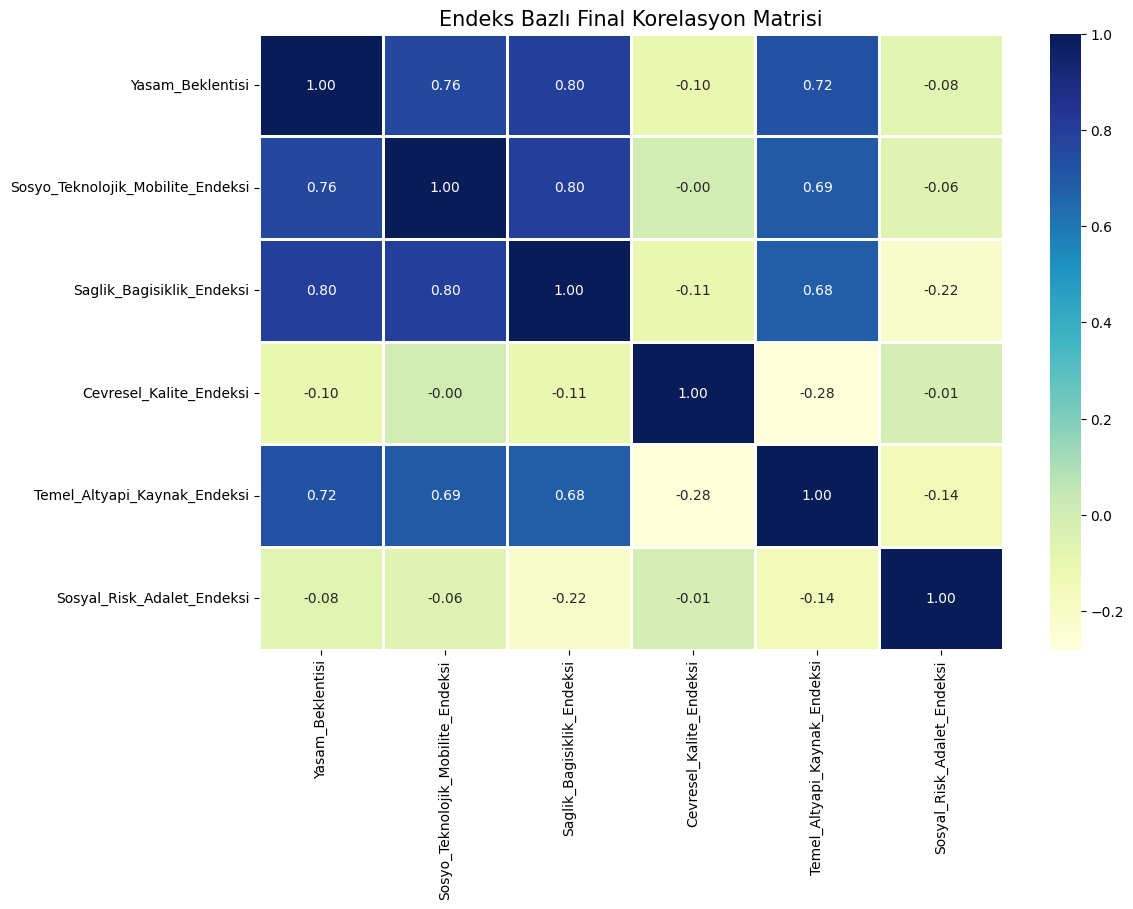

In [ ]:
# Sadece oluşturduğumuz ana endeksleri ve hedef değişkeni seçelim
final_index_cols = [
    'Yasam_Beklentisi',
    'Sosyo_Teknolojik_Mobilite_Endeksi',
    'Saglik_Bagisiklik_Endeksi',
    'Cevresel_Kalite_Endeksi',
    'Temel_Altyapi_Kaynak_Endeksi',
    'Sosyal_Risk_Adalet_Endeksi'
]

# Korelasyon matrisini hesapla
final_corr = df_combined[final_index_cols].corr()

# Isı haritasını çizdir
plt.figure(figsize=(12, 8))
sns.heatmap(final_corr, annot=True, fmt=".2f", cmap='YlGnBu', linewidths=1)
plt.title('Endeks Bazlı Final Korelasyon Matrisi', fontsize=15)
plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
import xgboost as xgb
from sklearn.metrics import r2_score, root_mean_squared_error
from sklearn.model_selection import train_test_split
# 1. Özellikler (X) ve Hedef (y) Belirleme
features = [
    'Sosyo_Teknolojik_Mobilite_Endeksi',
    'Saglik_Bagisiklik_Endeksi',
    'Cevresel_Kalite_Endeksi',
    'Temel_Altyapi_Kaynak_Endeksi',
    'Sosyal_Risk_Adalet_Endeksi',
    'Is_Pandemic'
]

X = df_combined[features]
y = df_combined['Yasam_Beklentisi']

# 2. Veriyi Eğitim ve Test olarak ayırma (%80 Eğitim, %20 Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Lasso Regression": Lasso(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "XGBoost": xgb.XGBRegressor(n_estimators=1000, learning_rate=0.05, max_depth=6, random_state=42),
    "SVR": SVR(kernel='rbf')
}

# 3. Eğitim ve Değerlendirme Döngüsü
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    r2 = r2_score(y_test, predictions)
    rmse = root_mean_squared_error(y_test, predictions)

    results.append({"Model": name, "R2 Score": r2, "RMSE": rmse})

# 4. Sonuçları Tablo Haline Getirme
df_results = pd.DataFrame(results).sort_values(by="R2 Score", ascending=False)
print(df_results)

               Model  R2 Score      RMSE
3      Random Forest  0.972261  1.035902
5            XGBoost  0.970900  1.061012
4  Gradient Boosting  0.927017  1.680295
6                SVR  0.759184  3.052238
0  Linear Regression  0.724769  3.263057
1   Ridge Regression  0.723422  3.271028
2   Lasso Regression -0.000836  6.222390


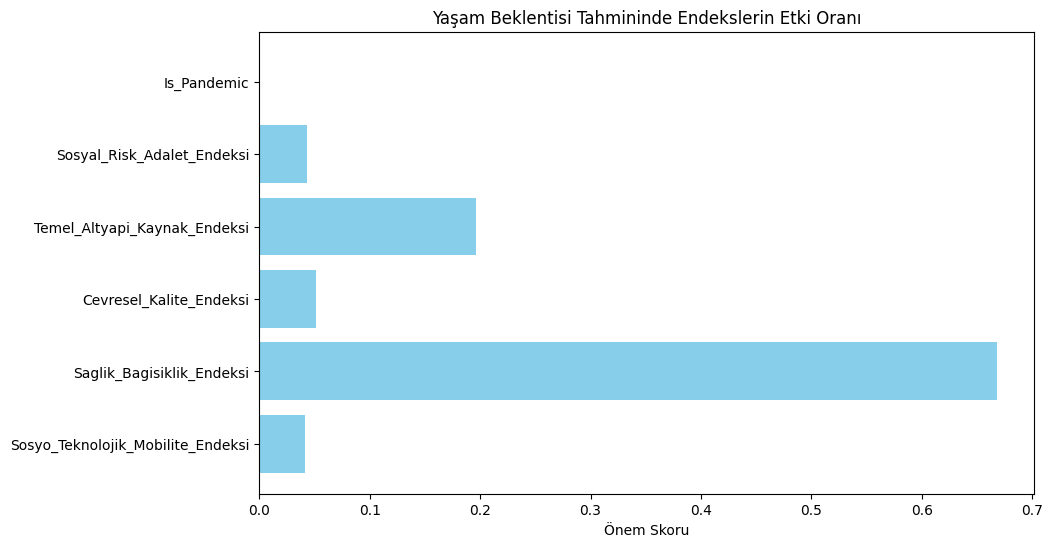

In [ ]:
import matplotlib.pyplot as plt

# Random Forest modelinin özellik önemini alalım
importances = models["Random Forest"].feature_importances_
feature_names = features

# Görselleştirme
plt.figure(figsize=(10, 6))
plt.barh(feature_names, importances, color='skyblue')
plt.xlabel('Önem Skoru')
plt.title('Yaşam Beklentisi Tahmininde Endekslerin Etki Oranı')
plt.show()

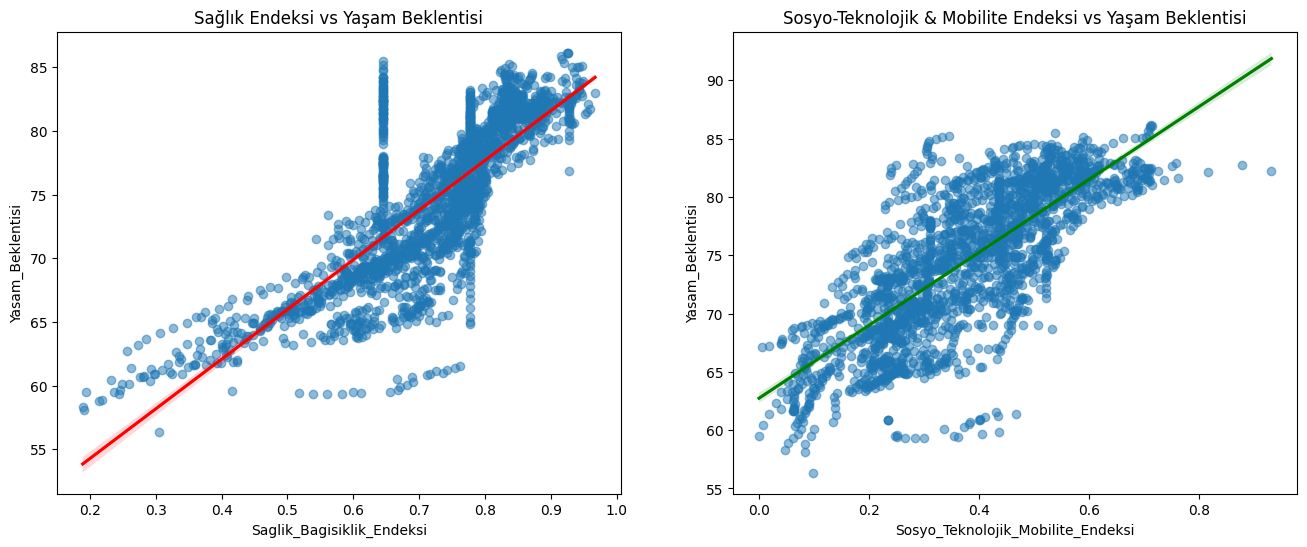

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# En önemli iki endeks için scatter plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sağlık Endeksi vs Yaşam Beklentisi
sns.regplot(x='Saglik_Bagisiklik_Endeksi', y='Yasam_Beklentisi', data=df_combined,
            ax=axes[0], scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
axes[0].set_title('Sağlık Endeksi vs Yaşam Beklentisi')

# Sosyo-Teknolojik Endeks vs Yaşam Beklentisi
sns.regplot(x='Sosyo_Teknolojik_Mobilite_Endeksi', y='Yasam_Beklentisi', data=df_combined,
            ax=axes[1], scatter_kws={'alpha':0.5}, line_kws={'color':'green'})
axes[1].set_title('Sosyo-Teknolojik & Mobilite Endeksi vs Yaşam Beklentisi')

plt.show()

In [ ]:
def yasam_beklentisi_simulasyonu(ulke_adi, yil):
    # Seçilen ülke ve yıla ait veriyi bul
    country_data = df_combined[(df_combined['Ulke_Adi'] == ulke_adi) & (df_combined['Yil'] == yil)]

    if country_data.empty:
        return "Veri bulunamadı."

    # Orijinal endeks değerlerini al
    current_values = country_data[features].values
    current_prediction = models["Random Forest"].predict(current_values)[0]

    print(f"--- {ulke_adi} ({yil}) Simülasyonu ---")
    print(f"Mevcut Tahmini Yaşam Beklentisi: {current_prediction:.2f} Yıl")
    print("-" * 30)

    # Senaryo: Sağlık ve Mobilite endekslerinde %10 iyileşme yapalım
    improved_values = current_values.copy()
    improved_values[0, 0] *= 1.10 # Sosyo-Teknoloji %10 artış
    improved_values[0, 1] *= 1.10 # Sağlık %10 artış

    # Sınırlandırma (Endeks max 1 olabilir)
    improved_values = np.clip(improved_values, 0, 1)

    new_prediction = models["Random Forest"].predict(improved_values)[0]
    fark = new_prediction - current_prediction

    print(f"Senaryo: Sağlık ve Dijital/Mobilite yatırımları %10 artırıldı.")
    print(f"Yeni Tahmini Yaşam Beklentisi: {new_prediction:.2f} Yıl")
    print(f"Tahmini Kazanç: +{fark:.2f} Yıl")

# Örnek Kullanım:
yasam_beklentisi_simulasyonu('Turkiye', 2019)

--- Turkiye (2019) Simülasyonu ---
Mevcut Tahmini Yaşam Beklentisi: 77.15 Yıl
------------------------------
Senaryo: Sağlık ve Dijital/Mobilite yatırımları %10 artırıldı.
Yeni Tahmini Yaşam Beklentisi: 82.30 Yıl
Tahmini Kazanç: +5.15 Yıl


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
